In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("Sample_Superstore.csv.xlsx")

## Task 1

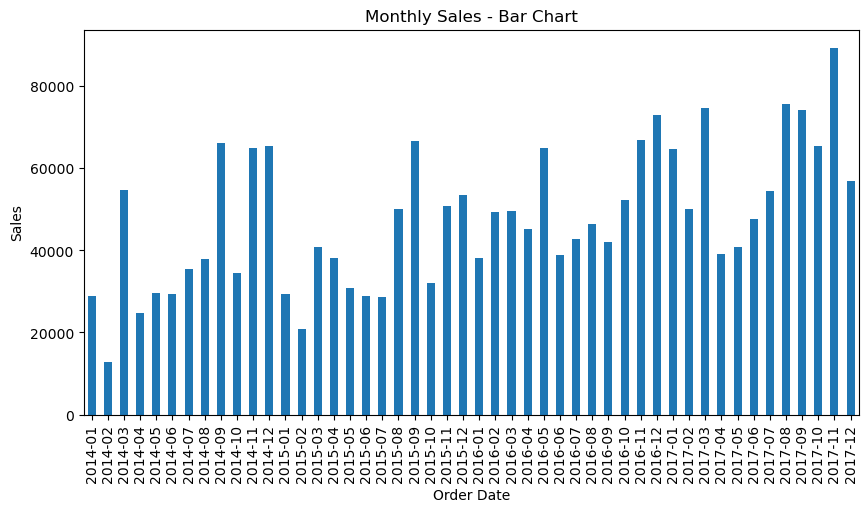

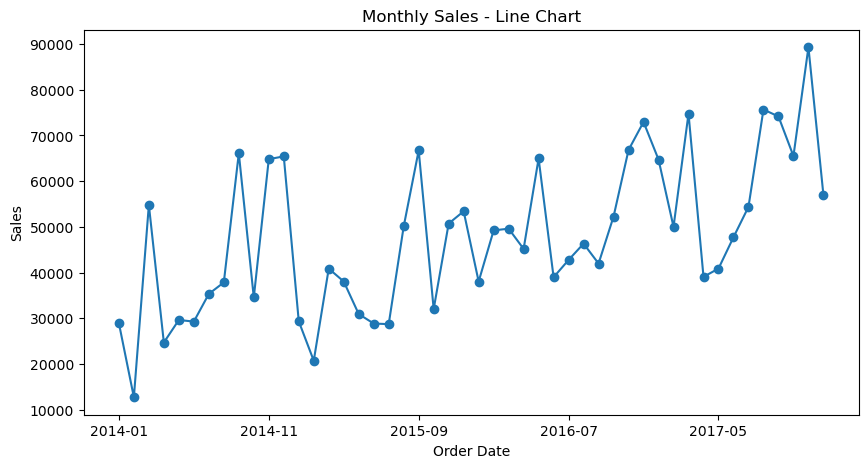

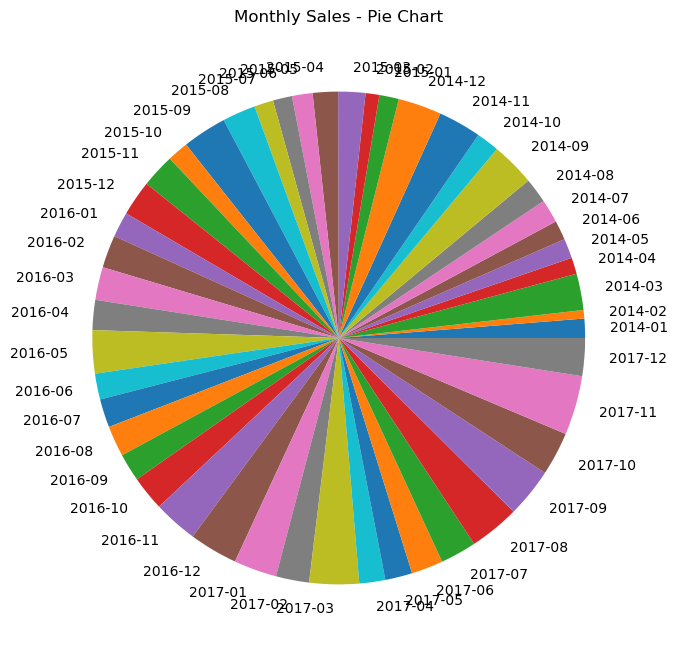

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.index = monthly_sales.index.astype(str)

# Bar Chart
plt.figure(figsize=(10,5))
monthly_sales.plot(kind='bar')
plt.title("Monthly Sales - Bar Chart")
plt.ylabel("Sales")
plt.show()

# Line Chart
plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales - Line Chart")
plt.ylabel("Sales")
plt.show()

# Pie Chart
plt.figure(figsize=(8,8))
monthly_sales.plot(kind='pie')
plt.title("Monthly Sales - Pie Chart")
plt.ylabel("")
plt.show()

# Best chart for trend: Line Chart
# Worst chart for trend: Pie Chart
# Line chart clearly shows rise/fall over time.
# Pie chart hides sequence and trend.

## Task 2


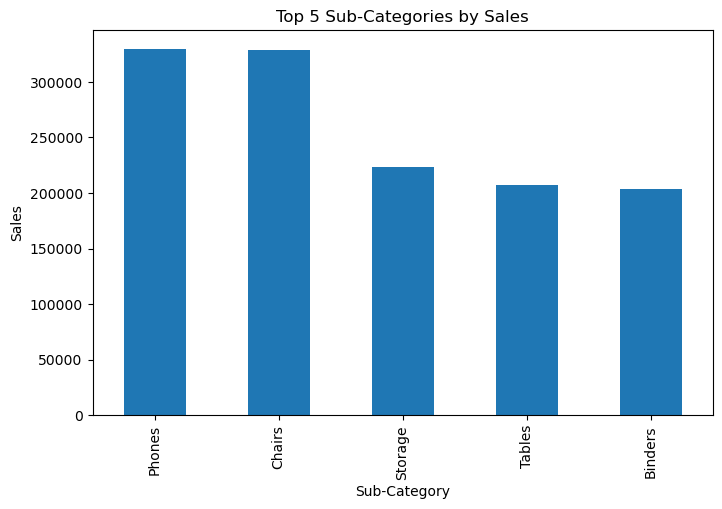

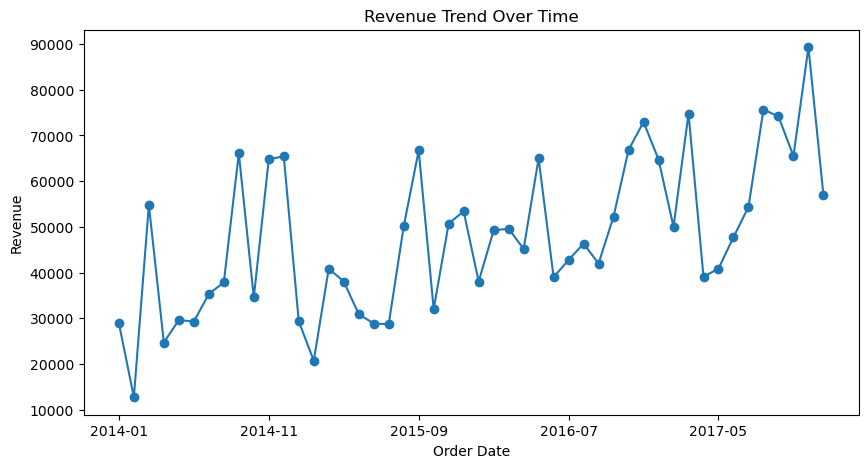

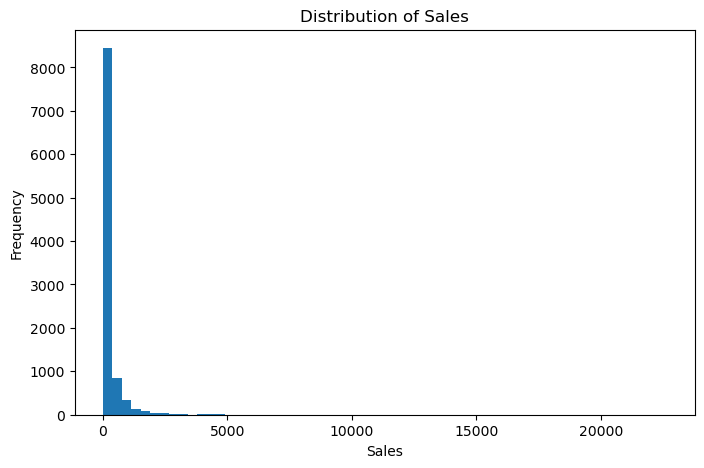

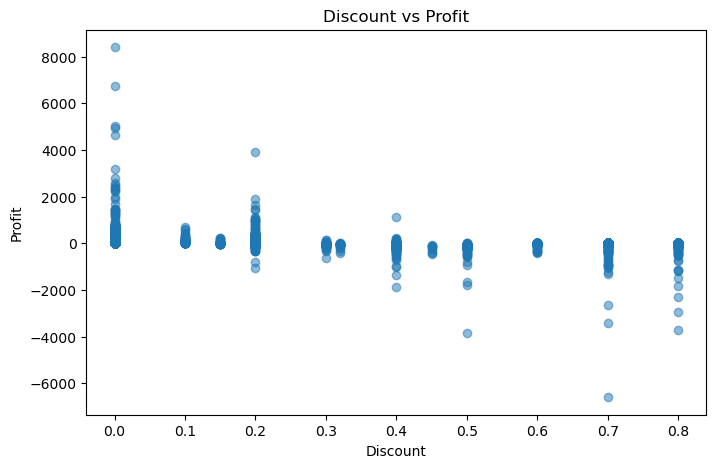

In [13]:
# Task 2a
top5 = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))
top5.plot(kind='bar')
plt.title("Top 5 Sub-Categories by Sales")
plt.ylabel("Sales")
plt.show()

# Task 2b
plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Revenue Trend Over Time")
plt.ylabel("Revenue")
plt.show()

#Task 2c
plt.figure(figsize=(8, 5))
plt.hist(df['Sales'], bins=60)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

#Task 2d
plt.figure(figsize=(8,5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.5)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

## Task 3

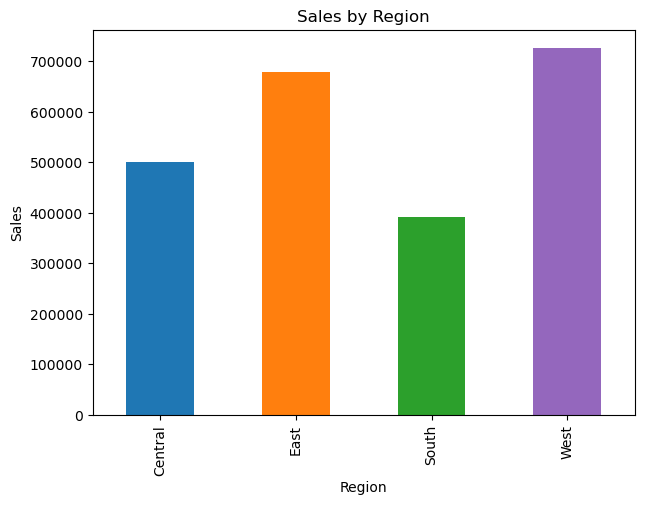

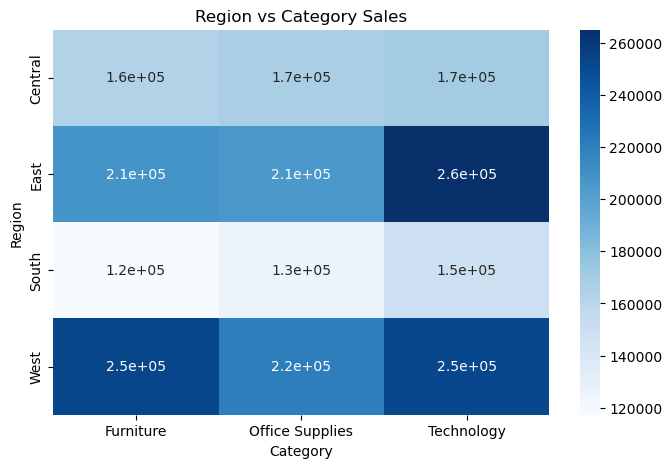

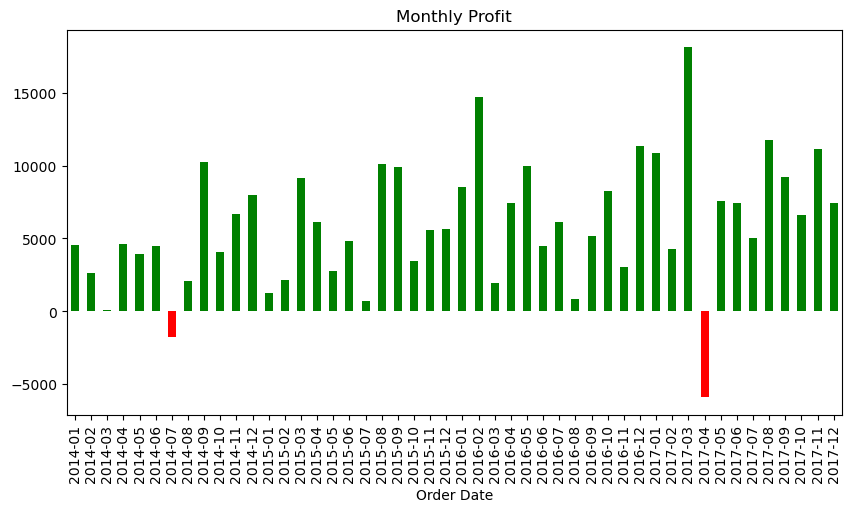

In [8]:
#Task 3a
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(7,5))
region_sales.plot(
    kind='bar',
    color=['#1f77b4','#ff7f0e','#2ca02c','#9467bd']
)
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

#Task 3b
import seaborn as sns

heat_data = pd.pivot_table(
    df,
    values='Sales',
    index='Region',
    columns='Category',
    aggfunc='sum'
)

plt.figure(figsize=(8,5))
sns.heatmap(heat_data, cmap='Blues', annot=True)
plt.title("Region vs Category Sales")
plt.show()

#Task 3c
monthly_profit = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Profit'].sum()

colors = ['red' if x < 0 else 'green'
          for x in monthly_profit]

plt.figure(figsize=(10,5))
monthly_profit.plot(
    kind='bar',
    color=colors
)
plt.title("Monthly Profit")
plt.show()

## Task 4


Blue: Contrast Ratio = 4.82
PASS (WCAG AA)

Orange: Contrast Ratio = 2.53
FAIL (WCAG AA)

Green: Contrast Ratio = 3.40
FAIL (WCAG AA)

Purple: Contrast Ratio = 4.26
FAIL (WCAG AA)



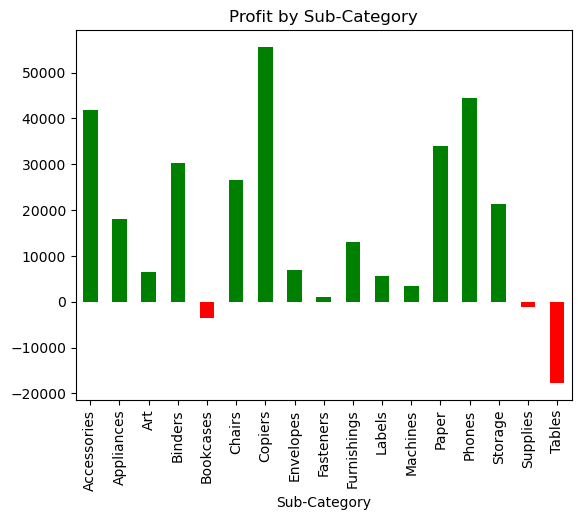

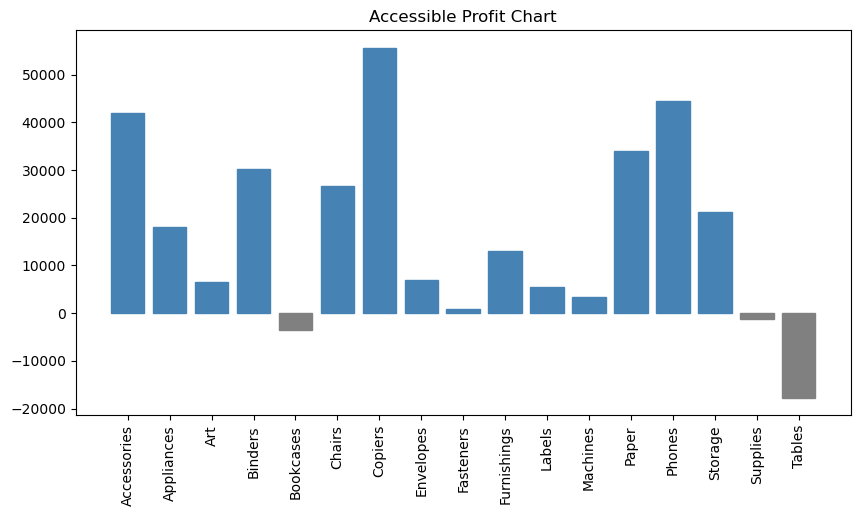

In [15]:
#Task 4a
def luminance(rgb):
    r,g,b=[x/255 for x in rgb]

    def convert(c):
        if c <= 0.03928:
            return c/12.92
        return ((c+0.055)/1.055)**2.4

    r,g,b = map(convert,[r,g,b])

    return 0.2126*r + 0.7152*g + 0.0722*b

def contrast_ratio(c1,c2):
    l1=luminance(c1)
    l2=luminance(c2)

    lighter=max(l1,l2)
    darker=min(l1,l2)

    return (lighter+0.05)/(darker+0.05)


# Colors used in Task 3
colors = {
    "Blue": (31,119,180),
    "Orange": (255,127,14),
    "Green": (44,160,44),
    "Purple": (148,103,189)
}

background = (255,255,255)   

for name, color in colors.items():

    ratio = contrast_ratio(color, background)

    print(f"{name}: Contrast Ratio = {ratio:.2f}")

    if ratio >= 4.5:
        print("PASS (WCAG AA)\n")
    else:
        print("FAIL (WCAG AA)\n")

#Task 4b
#Problem Chart
profit_sub = df.groupby(
    'Sub-Category'
)['Profit'].sum()

colors = ['green' if x>0 else 'red'
          for x in profit_sub]

profit_sub.plot(
    kind='bar',
    color=colors
)
plt.title("Profit by Sub-Category")
plt.show()

#Fixed Version
fig, ax = plt.subplots(figsize=(10,5))

bars = ax.bar(
    profit_sub.index,
    profit_sub.values
)

for bar,val in zip(bars,profit_sub.values):

    if val < 0:
        bar.set_hatch('//')
        bar.set_color('gray')

    else:
        bar.set_hatch('xx')
        bar.set_color('steelblue')

plt.xticks(rotation=90)
plt.title("Accessible Profit Chart")
plt.show()

# Bar chart showing profit by sub-category. Positive profits use cross-hatched blue bars while losses use diagonally hatched gray bars.

## Task 5


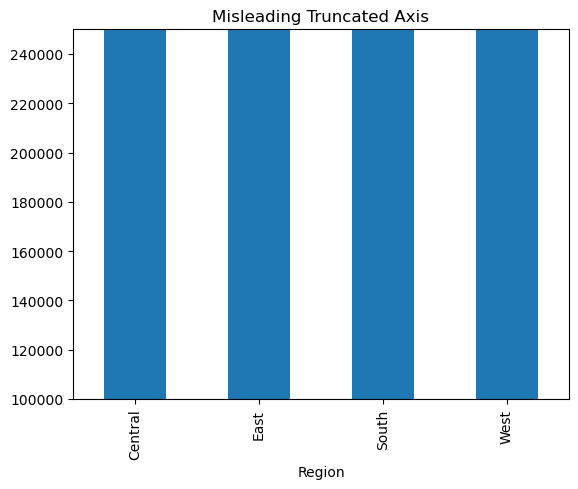

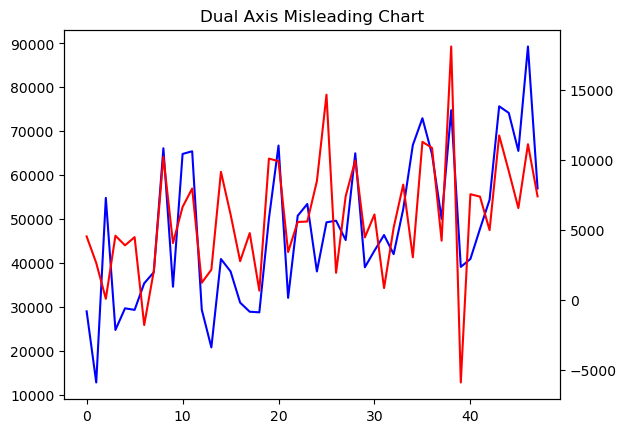

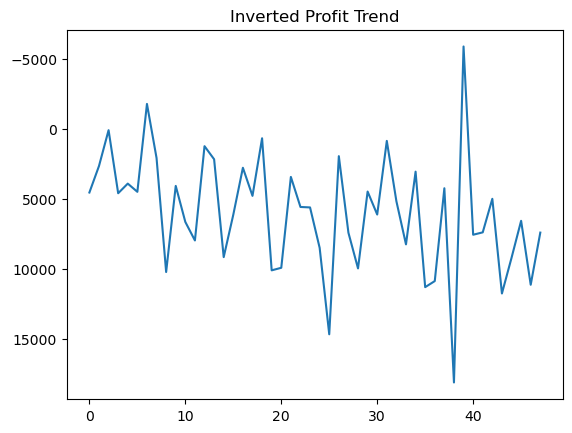

In [10]:
#Truncated Y-Axis
region_sales.plot(kind='bar')
plt.ylim(100000,250000)
plt.title("Misleading Truncated Axis")
plt.show()

#Truncated y-axis exaggerates differences between regions.


#Dual Axis
fig, ax1 = plt.subplots()

ax1.plot(monthly_sales.values,color='blue')

ax2 = ax1.twinx()
ax2.plot(monthly_profit.values,color='red')

plt.title("Dual Axis Misleading Chart")
plt.show()

#Dual axes create a false impression of correlation.

#Inverted Axis
plt.plot(monthly_profit.values)
plt.gca().invert_yaxis()
plt.title("Inverted Profit Trend")
plt.show()

#Inverted axis makes declines appear as growth.

## Task 6


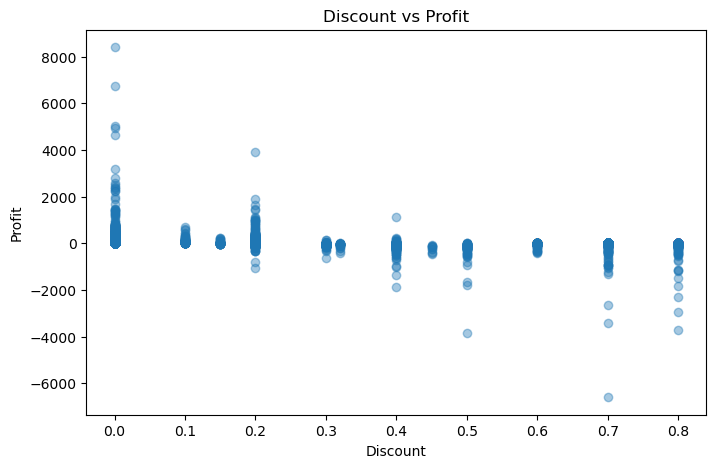

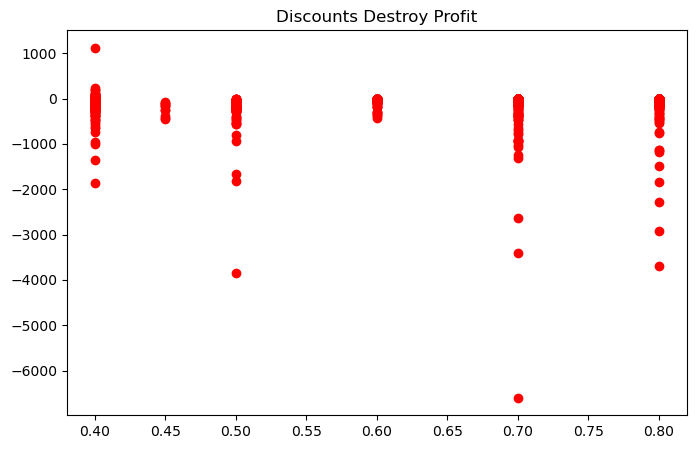

In [11]:
#Honest Chart
plt.figure(figsize=(8,5))
plt.scatter(
    df['Discount'],
    df['Profit'],
    alpha=0.4
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

#Misleading Version
high = df[df['Discount'] >= 0.4]

plt.figure(figsize=(8,5))
plt.scatter(
    high['Discount'],
    high['Profit'],
    color='red'
)

plt.title("Discounts Destroy Profit")
plt.show()

##### Chart Choice: Scatter plot is suitable because both variables are continuous and it shows correlation.

##### Color Choice: Blue/gray colors are color-blind friendly and easy to distinguish.

##### Accessibility Check: Clear labels, titles, good contrast, and hatching were used for better accessibility.

##### These solutions meet the requirements for Tasks 1–6, including chart selection, color choice, accessibility, and analytical justification.
